# POS delay — analisi di sensibilità one-at-a-time del detector

Questo notebook analizza la sensibilità del detector POS delay rispetto ai principali parametri della procedura di rilevazione.

A partire dalla configurazione base fissata in `POS_delay_utils.py`, viene modificato un solo parametro alla volta, mantenendo invariati tutti gli altri:

```python
score_col = "pos_cos"
profile_window_size = 7
z_threshold = 3.5
min_consecutive = 2
gap_tolerance = 1
detected_window_mode = "profile_windows_union"
iou_threshold = 0.20
```

La ground truth viene usata soltanto per valutare, a posteriori, come cambiano precision, recall, \(F_1\) e allineamento temporale al variare di una singola scelta del detector.

L'analisi è limitata ai dataset con `source_duration = 1`, coerentemente con il caso principale discusso per il POS delay.


In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/ciok4/jupyter file/tesi')

## Import e dipendenze

Gli artifact sono centralizzati in `project_paths.py`. Le utility POS condivise gestiscono inference, detector event-level e metriche pooled.

La griglia one-at-a-time è costruita con la stessa utility usata nell'analisi di sensibilità del caso sales.

In [2]:
# =========================================================
# IMPORTS
# =========================================================

import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from matplotlib.ticker import FormatStrFormatter
from IPython.display import display
from tqdm.auto import tqdm

from project_paths import (
    POS_DELAY_RESULTS_DIR,
    POS_DELAY_SENSITIVITY_DIR,
    POS_MODEL_DIR,
    ensure_artifact_directories,
)

from POS_delay_utils import (
    POS_DELAY_DETECTOR_CONFIG,
    compute_results_for_dataset,
    list_pos_delay_sensitivity_datasets,
    make_pos_delay_cache_path,
    pooled_f1,
    pooled_precision,
    pooled_recall,
    run_detector_config_on_results,
)

from lstm_utils import (
    build_one_at_a_time_config_df,
    summarize_gt_eval_by_type,
)

pd.set_option("display.max_columns", None)

## Configurazione, path e cache

I dataset e il modello POS coincidono con quelli usati nei notebook 01 e 02. La configurazione base del detector viene letta da `POS_DELAY_DETECTOR_CONFIG`.

Con `FORCE_RECOMPUTE = False`, il notebook carica i risultati raw già salvati quando coprono tutti i dataset e le configurazioni dell'esperimento corrente. In questo caso il ciclo di detection non viene rieseguito.

La cache dell'inference resta disponibile quando i risultati raw devono essere rigenerati. `FORCE_RECOMPUTE_INFERENCE` ha effetto solo in quel caso.


In [3]:
# =========================================================
# CONFIG
# =========================================================

ensure_artifact_directories()

BASE_SENSITIVITY_PATH = POS_DELAY_SENSITIVITY_DIR
MODEL_DIR = POS_MODEL_DIR

OUTPUT_DIR = POS_DELAY_RESULTS_DIR / "detector_sensitivity_one_at_a_time"
INFERENCE_CACHE_DIR = OUTPUT_DIR / "_inference_cache"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

for path in [OUTPUT_DIR, INFERENCE_CACHE_DIR, TABLES_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RAW_RESULTS_PATH = (
    TABLES_DIR / "detector_sensitivity_one_at_a_time_raw.csv"
)
BY_TYPE_RESULTS_PATH = (
    TABLES_DIR / "detector_sensitivity_one_at_a_time_by_type_raw.csv"
)

# L'analisi one-at-a-time resta riferita al caso principale con un source day.
SOURCE_DURATION_FILTER = [1]

DELAY_TYPES_FILTER = [
    "mild_delay",
    "moderate_delay",
    "strong_delay",
    "batch_backlog",
    "settlement_freeze",
]

# Finestra del modello LSTM POS selezionato.
WINDOW_SIZE = 7

# Se True, ignora i risultati raw salvati e riesegue l'intera griglia.
FORCE_RECOMPUTE = False

# Se True, ricalcola l'inference per dataset durante una nuova esecuzione della griglia.
FORCE_RECOMPUTE_INFERENCE = False

# Limita il numero di dataset elaborati durante il debug.
DEBUG_MAX_DATASETS = None

# La configurazione base è la stessa usata nella sensitivity POS principale.
BASE_CONFIG = {
    key: POS_DELAY_DETECTOR_CONFIG[key]
    for key in [
        "score_col",
        "profile_window_size",
        "z_threshold",
        "min_consecutive",
        "gap_tolerance",
        "iou_threshold",
    ]
}

CONFIG = {
    "source_duration_filter": SOURCE_DURATION_FILTER,
    "delay_types_filter": DELAY_TYPES_FILTER,
    "window_size": WINDOW_SIZE,
    "base_detector_config": BASE_CONFIG,
    "force_recompute": FORCE_RECOMPUTE,
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BASE_SENSITIVITY_PATH:", BASE_SENSITIVITY_PATH)
print("MODEL_DIR:", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("INFERENCE_CACHE_DIR:", INFERENCE_CACHE_DIR)
print("RAW_RESULTS_PATH:", RAW_RESULTS_PATH)
display(pd.Series(CONFIG, dtype=object))

PROJECT_ROOT: C:\Users\ciok4\jupyter file\tesi
BASE_SENSITIVITY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\pos_delay\sensitivity
MODEL_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\models\pos
OUTPUT_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\detector_sensitivity_one_at_a_time
INFERENCE_CACHE_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\detector_sensitivity_one_at_a_time\_inference_cache
RAW_RESULTS_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\detector_sensitivity_one_at_a_time\tables\detector_sensitivity_one_at_a_time_raw.csv


source_duration_filter                                                  [1]
delay_types_filter        [mild_delay, moderate_delay, strong_delay, bat...
window_size                                                               7
base_detector_config      {'score_col': 'pos_cos', 'profile_window_size'...
force_recompute                                                       False
dtype: object

## Griglia one-at-a-time

La griglia non contiene tutte le combinazioni possibili. Ogni configurazione parte da `BASE_CONFIG` e modifica un solo parametro, così da rendere interpretabile l'effetto marginale di ciascuna scelta del detector.

I parametri analizzati sono:

- `score_col`: metrica di distanza tra profilo POS osservato e atteso;
- `profile_window_size`: ampiezza della finestra di profilo sui business days;
- `z_threshold`: soglia applicata allo z-score stimato sul validation set;
- `min_consecutive`: numero minimo di finestre consecutive sopra soglia;
- `gap_tolerance`: tolleranza nel merge di finestre quasi contigue.


In [4]:
# =========================================================
# ONE-AT-A-TIME CONFIGS
# =========================================================

PARAMETER_VALUES = {
    "score_col": [
        "pos_cos",
        "pos_wasserstein",
        "pos_l1",
    ],
    "profile_window_size": [
        3,
        5,
        7,
        9,
    ],
    "z_threshold": [
        2.5,
        3.0,
        3.5,
        4.0,
        4.5,
    ],
    "min_consecutive": [
        1,
        2,
        3,
        4,
    ],
    "gap_tolerance": [
        0,
        1,
        2,
    ],
}

detector_configs = build_one_at_a_time_config_df(
    BASE_CONFIG,
    PARAMETER_VALUES,
)

display(detector_configs)

,config_id,variation_group,varied_parameter,varied_value,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,iou_threshold
0,0,base_config,base_config,reference,pos_cos,7,3.5,2,1,0.2
1,1,score_col,score_col,pos_cos,pos_cos,7,3.5,2,1,0.2
2,2,score_col,score_col,pos_wasserstein,pos_wasserstein,7,3.5,2,1,0.2
3,3,score_col,score_col,pos_l1,pos_l1,7,3.5,2,1,0.2
4,4,profile_window_size,profile_window_size,3,pos_cos,3,3.5,2,1,0.2
5,5,profile_window_size,profile_window_size,5,pos_cos,5,3.5,2,1,0.2
6,6,profile_window_size,profile_window_size,7,pos_cos,7,3.5,2,1,0.2
7,7,profile_window_size,profile_window_size,9,pos_cos,9,3.5,2,1,0.2
8,8,z_threshold,z_threshold,2.5,pos_cos,7,2.5,2,1,0.2
9,9,z_threshold,z_threshold,3.0,pos_cos,7,3.0,2,1,0.2


## Modello POS e dataset di sensitivity

I dataset seguono la stessa struttura e gli stessi filtri dell'analisi di sensitivity principale. Il modello POS e gli artifact di preprocessing vengono caricati solo quando i risultati raw devono essere rigenerati.


In [5]:
# =========================================================
# LOAD MODEL
# =========================================================

model = None
feature_scalers = None
mappings = None
features = None


def load_pos_model_artifacts():
    """Carica il modello POS e gli artifact di preprocessing una sola volta."""

    global model, feature_scalers, mappings, features

    if model is not None:
        return

    model = tf.keras.models.load_model(
        MODEL_DIR / "lstm_pos.keras"
    )

    with open(MODEL_DIR / "feature_scalers.pkl", "rb") as f:
        feature_scalers = pickle.load(f)

    with open(MODEL_DIR / "mappings.pkl", "rb") as f:
        mappings = pickle.load(f)

    with open(MODEL_DIR / "features.pkl", "rb") as f:
        features = pickle.load(f)


In [6]:
# =========================================================
# LIST SENSITIVITY DATASETS
# =========================================================

datasets_df = list_pos_delay_sensitivity_datasets(
    BASE_SENSITIVITY_PATH,
    source_duration_filter=SOURCE_DURATION_FILTER,
    delay_types_filter=DELAY_TYPES_FILTER,
)

if datasets_df.empty:
    raise FileNotFoundError(
        "Nessun dataset POS delay trovato. Controlla BASE_SENSITIVITY_PATH "
        "e i filtri SOURCE_DURATION_FILTER / DELAY_TYPES_FILTER."
    )

datasets_df = datasets_df.sort_values(
    ["delay_type", "source_duration", "seed"]
).reset_index(drop=True)

if DEBUG_MAX_DATASETS is not None:
    datasets_df = datasets_df.head(DEBUG_MAX_DATASETS).copy()

print("Numero dataset:", len(datasets_df))
display(datasets_df.head())


Numero dataset: 25


,path,delay_type,source_duration,seed
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,42
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,43
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,44
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,45
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,46


In [7]:
# Copertura degli esperimenti disponibili.
experiment_coverage = (
    datasets_df
    .groupby(["source_duration", "delay_type"])
    .size()
    .rename("n_datasets")
    .reset_index()
)

display(experiment_coverage)


,source_duration,delay_type,n_datasets
0,1,batch_backlog,5
1,1,mild_delay,5
2,1,moderate_delay,5
3,1,settlement_freeze,5
4,1,strong_delay,5


## Cache dell'inference e dei risultati

L'inference del modello POS viene salvata per dataset. Al termine della griglia vengono salvati anche i risultati raw della detection.

Al riavvio, i CSV raw vengono riutilizzati soltanto se contengono tutte le combinazioni dataset--configurazione richieste dalla griglia corrente.


In [8]:
RESULT_CACHE_KEY_COLUMNS = [
    "delay_type_dataset",
    "source_duration",
    "seed",
    "config_id",
    "variation_group",
    "score_col",
    "profile_window_size",
    "z_threshold",
    "min_consecutive",
    "gap_tolerance",
    "iou_threshold",
]


def build_expected_result_keys(datasets_df, detector_configs):
    """Costruisce le combinazioni dataset-configurazione richieste."""

    datasets = datasets_df[
        ["delay_type", "source_duration", "seed"]
    ].rename(columns={"delay_type": "delay_type_dataset"}).copy()

    configs = detector_configs[
        [
            "config_id",
            "variation_group",
            "score_col",
            "profile_window_size",
            "z_threshold",
            "min_consecutive",
            "gap_tolerance",
            "iou_threshold",
        ]
    ].copy()

    datasets["_join_key"] = 1
    configs["_join_key"] = 1

    return datasets.merge(configs, on="_join_key").drop(columns="_join_key")


def normalize_result_cache_keys(df):
    """Normalizza le colonne usate per verificare la copertura della cache."""

    out = df.copy()

    integer_columns = [
        "source_duration",
        "seed",
        "config_id",
        "profile_window_size",
        "min_consecutive",
        "gap_tolerance",
    ]
    float_columns = ["z_threshold", "iou_threshold"]
    text_columns = [
        "delay_type_dataset",
        "variation_group",
        "score_col",
    ]

    for column in integer_columns:
        out[column] = pd.to_numeric(
            out[column],
            errors="coerce",
        ).astype("Int64")

    for column in float_columns:
        out[column] = pd.to_numeric(
            out[column],
            errors="coerce",
        ).round(12)

    for column in text_columns:
        out[column] = out[column].astype(str)

    return out


def load_cached_results_if_complete():
    """Carica i risultati raw solo quando coprono l'esperimento corrente."""

    if (
        FORCE_RECOMPUTE
        or not RAW_RESULTS_PATH.exists()
        or not BY_TYPE_RESULTS_PATH.exists()
    ):
        return None

    try:
        cached_raw = pd.read_csv(RAW_RESULTS_PATH)
        cached_by_type = pd.read_csv(BY_TYPE_RESULTS_PATH)
    except (OSError, pd.errors.ParserError) as error:
        print(f"Cache risultati non leggibile: {error}")
        return None

    required_columns = set(RESULT_CACHE_KEY_COLUMNS)

    if (
        cached_raw.empty
        or cached_by_type.empty
        or not required_columns.issubset(cached_raw.columns)
        or not required_columns.issubset(cached_by_type.columns)
    ):
        return None

    expected_keys = normalize_result_cache_keys(
        build_expected_result_keys(datasets_df, detector_configs)
    )[RESULT_CACHE_KEY_COLUMNS].drop_duplicates()

    raw_keys = normalize_result_cache_keys(
        cached_raw[RESULT_CACHE_KEY_COLUMNS]
    ).drop_duplicates()

    by_type_keys = normalize_result_cache_keys(
        cached_by_type[RESULT_CACHE_KEY_COLUMNS]
    ).drop_duplicates()

    missing_raw = expected_keys.merge(
        raw_keys,
        on=RESULT_CACHE_KEY_COLUMNS,
        how="left",
        indicator=True,
    )
    missing_by_type = expected_keys.merge(
        by_type_keys,
        on=RESULT_CACHE_KEY_COLUMNS,
        how="left",
        indicator=True,
    )

    if (
        (missing_raw["_merge"] != "both").any()
        or (missing_by_type["_merge"] != "both").any()
    ):
        return None

    cached_raw = normalize_result_cache_keys(cached_raw)
    cached_by_type = normalize_result_cache_keys(cached_by_type)

    raw_results = cached_raw.merge(
        expected_keys,
        on=RESULT_CACHE_KEY_COLUMNS,
        how="inner",
    )
    by_type_results = cached_by_type.merge(
        expected_keys,
        on=RESULT_CACHE_KEY_COLUMNS,
        how="inner",
    )

    return raw_results, by_type_results


def compute_or_load_results(dataset_row):
    """Carica da cache oppure calcola train, validation e test results per un dataset."""

    cache_path = make_pos_delay_cache_path(
        dataset_row,
        INFERENCE_CACHE_DIR,
    )

    if cache_path.exists() and not FORCE_RECOMPUTE_INFERENCE:
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    load_pos_model_artifacts()

    dataset_cache = compute_results_for_dataset(
        csv_path=dataset_row["path"],
        model=model,
        feature_scalers=feature_scalers,
        mappings=mappings,
        features=features,
        window_size=WINDOW_SIZE,
    )

    with open(cache_path, "wb") as f:
        pickle.dump(dataset_cache, f)

    return dataset_cache


## Valutazione della griglia

Per ogni dataset e per ogni configurazione:

1. si costruiscono le profile window;
2. si calcola lo z-score usando il validation split come riferimento normale;
3. si applica il detector;
4. si valuta il risultato a livello evento sul test split.

La ground truth viene usata solo per misurare il risultato della configurazione, non per selezionare una configurazione finale.


In [9]:
# =========================================================
# RUNNER
# =========================================================


def run_one_config_on_dataset(dataset_row, dataset_cache, config_row):
    """
    Esegue una configurazione del detector su un dataset già inferito.
    """

    val_results = dataset_cache["val_results"]
    test_results = dataset_cache["test_results"]

    output = run_detector_config_on_results(
        val_results=val_results,
        test_results=test_results,
        profile_window_size=int(config_row["profile_window_size"]),
        score_col=config_row["score_col"],
        z_threshold=float(config_row["z_threshold"]),
        min_consecutive=int(config_row["min_consecutive"]),
        gap_tolerance=int(config_row["gap_tolerance"]),
        iou_threshold=float(config_row["iou_threshold"]),
    )

    return output


def make_summary_row(dataset_row, config_row, detector_output):
    """
    Costruisce una riga di sintesi per il dataset e la configurazione corrente.
    """

    row = {
        "delay_type_dataset": dataset_row["delay_type"],
        "source_duration": int(dataset_row["source_duration"]),
        "seed": int(dataset_row["seed"]),
        "path": str(dataset_row["path"]),
        "config_id": int(config_row["config_id"]),
        "variation_group": config_row["variation_group"],
        "varied_parameter": config_row["varied_parameter"],
        "varied_value": config_row["varied_value"],
        "score_col": config_row["score_col"],
        "profile_window_size": int(config_row["profile_window_size"]),
        "z_threshold": float(config_row["z_threshold"]),
        "min_consecutive": int(config_row["min_consecutive"]),
        "gap_tolerance": int(config_row["gap_tolerance"]),
        "iou_threshold": float(config_row["iou_threshold"]),
    }

    row.update(detector_output["summary"])

    return row


def make_by_type_rows(dataset_row, config_row, detector_output):
    """
    Costruisce le righe di sintesi per tipo di POS delay.
    """

    gt_eval = detector_output["gt_eval"]

    if gt_eval.empty:
        return []

    by_type = summarize_gt_eval_by_type(gt_eval)

    rows = []

    for _, r in by_type.iterrows():
        row = {
            "delay_type_dataset": dataset_row["delay_type"],
            "source_duration": int(dataset_row["source_duration"]),
            "seed": int(dataset_row["seed"]),
            "config_id": int(config_row["config_id"]),
            "variation_group": config_row["variation_group"],
            "varied_parameter": config_row["varied_parameter"],
            "varied_value": config_row["varied_value"],
            "score_col": config_row["score_col"],
            "profile_window_size": int(config_row["profile_window_size"]),
            "z_threshold": float(config_row["z_threshold"]),
            "min_consecutive": int(config_row["min_consecutive"]),
            "gap_tolerance": int(config_row["gap_tolerance"]),
            "iou_threshold": float(config_row["iou_threshold"]),
        }

        row.update(r.to_dict())
        rows.append(row)

    return rows

## Esecuzione dell'analisi

Se i risultati raw disponibili coprono l'esperimento corrente, vengono caricati direttamente. Altrimenti l'inference viene riusata per dataset e la griglia agisce soltanto sulla detection.


In [10]:
# =========================================================
# RUN SENSITIVITY
# =========================================================

cached_results = load_cached_results_if_complete()

if cached_results is not None:
    raw_results, by_type_results = cached_results

    print("Risultati completi caricati da cache.")
    print("Raw:", RAW_RESULTS_PATH)
    print("By type:", BY_TYPE_RESULTS_PATH)

else:
    start_time = time.time()

    summary_rows = []
    by_type_rows = []

    print(f"Dataset da processare: {len(datasets_df)}")
    print(f"Configurazioni one-at-a-time: {len(detector_configs)}")
    print(f"Run totali detector: {len(datasets_df) * len(detector_configs)}")

    for _, dataset_row in tqdm(
        datasets_df.iterrows(),
        total=len(datasets_df),
        desc="Datasets",
    ):
        dataset_cache = compute_or_load_results(dataset_row)

        for _, config_row in detector_configs.iterrows():
            detector_output = run_one_config_on_dataset(
                dataset_row=dataset_row,
                dataset_cache=dataset_cache,
                config_row=config_row,
            )

            if detector_output is None:
                continue

            summary_rows.append(
                make_summary_row(
                    dataset_row=dataset_row,
                    config_row=config_row,
                    detector_output=detector_output,
                )
            )

            by_type_rows.extend(
                make_by_type_rows(
                    dataset_row=dataset_row,
                    config_row=config_row,
                    detector_output=detector_output,
                )
            )

    raw_results = pd.DataFrame(summary_rows)
    by_type_results = pd.DataFrame(by_type_rows)

    raw_results.to_csv(RAW_RESULTS_PATH, index=False)
    by_type_results.to_csv(BY_TYPE_RESULTS_PATH, index=False)

    elapsed = time.time() - start_time
    print(f"Completato in {elapsed:.1f} secondi")
    print("Risultati raw salvati in:", RAW_RESULTS_PATH)

raw_results.head()

Risultati completi caricati da cache.
Raw: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\detector_sensitivity_one_at_a_time\tables\detector_sensitivity_one_at_a_time_raw.csv
By type: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\detector_sensitivity_one_at_a_time\tables\detector_sensitivity_one_at_a_time_by_type_raw.csv


,delay_type_dataset,source_duration,seed,path,config_id,variation_group,varied_parameter,varied_value,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,iou_threshold,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_delay
0,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,0,base_config,base_config,reference,pos_cos,7,3.5,2,1,0.2,50,68,50,18,0,0.735294,1.00,0.847458,0.477820,-5.680000
1,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,1,score_col,score_col,pos_cos,pos_cos,7,3.5,2,1,0.2,50,68,50,18,0,0.735294,1.00,0.847458,0.477820,-5.680000
2,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,2,score_col,score_col,pos_wasserstein,pos_wasserstein,7,3.5,2,1,0.2,50,56,50,6,0,0.892857,1.00,0.943396,0.462668,-5.240000
3,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,3,score_col,score_col,pos_l1,pos_l1,7,3.5,2,1,0.2,50,49,46,3,4,0.938776,0.92,0.929293,0.548450,-4.217391
4,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,4,profile_window_size,profile_window_size,3,pos_cos,3,3.5,2,1,0.2,50,57,44,13,6,0.771930,0.88,0.822430,0.526501,-2.840909


## Tabelle principali

La prima tabella riassume la configurazione base; le successive aggregano la sensitivity per parametro e valore.

Le metriche pooled derivano dai conteggi aggregati di TP, FP e FN. Media e deviazione standard descrivono invece la variabilità tra run.


In [11]:
# =========================================================
# FORMAT HELPERS
# =========================================================

def round_metric_cols(df, digits=3):
    out = df.copy()
    for col in out.columns:
        if any(key in col for key in ["precision", "recall", "f1", "iou", "delay"]):
            out[col] = out[col].round(digits)
    return out


def aggregate_run_statistics(df, group_cols):
    """
    Aggrega media e deviazione standard delle metriche tra run.
    """

    return (
        df
        .groupby(group_cols, dropna=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events_mean=("n_gt_events", "mean"),
            n_detected_events_mean=("n_detected_events", "mean"),
            tp_mean=("tp", "mean"),
            fp_mean=("fp", "mean"),
            fn_mean=("fn", "mean"),
            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),
            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            mean_iou_mean=("mean_iou", "mean"),
            mean_iou_std=("mean_iou", "std"),
            mean_detection_delay_mean=("mean_detection_delay", "mean"),
            mean_detection_delay_std=("mean_detection_delay", "std"),
        )
        .reset_index()
    )

In [12]:
# =========================================================
# BASE CONFIG RESULTS
# =========================================================

base_results = raw_results[
    raw_results["variation_group"] == "base_config"
].copy()

base_summary = aggregate_run_statistics(
    base_results,
    group_cols=[
        "score_col",
        "profile_window_size",
        "z_threshold",
        "min_consecutive",
        "gap_tolerance",
    ],
)

round_metric_cols(base_summary)

,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,n_runs,n_gt_events_mean,n_detected_events_mean,tp_mean,fp_mean,fn_mean,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mean_iou_mean,mean_iou_std,mean_detection_delay_mean,mean_detection_delay_std
0,pos_cos,7,3.5,2,1,25,50.0,61.08,40.88,20.2,9.12,0.654,0.097,0.818,0.227,0.723,0.155,0.475,0.051,-5.422,0.82


In [13]:
# =========================================================
# BASE CONFIG BY DELAY TYPE
# =========================================================

if not by_type_results.empty:
    base_by_type = by_type_results[
        by_type_results["variation_group"] == "base_config"
    ].copy()

    base_by_type_summary = (
        base_by_type
        .groupby("gt_type", dropna=False)
        .agg(
            n_runs=("seed", "count"),
            n_events_mean=("n_events", "mean"),
            detected_events_mean=("detected_events", "mean"),
            recall_mean=("recall", "mean"),
            mean_iou_mean=("mean_iou", "mean"),
            mean_detection_delay_mean=("mean_detection_delay", "mean"),
            missed_events_mean=("missed_events", "mean"),
        )
        .reset_index()
        .sort_values("gt_type")
    )

    display(round_metric_cols(base_by_type_summary))
else:
    base_by_type_summary = pd.DataFrame()
    print("by_type_results vuoto.")

,gt_type,n_runs,n_events_mean,detected_events_mean,recall_mean,mean_iou_mean,mean_detection_delay_mean,missed_events_mean
0,batch_backlog,5,50.0,49.0,0.980,0.450,-6.168,1.0
1,mild_delay,5,50.0,21.2,0.424,0.535,-4.151,28.8
2,moderate_delay,5,50.0,36.4,0.728,0.509,-5.209,13.6
3,settlement_freeze,5,50.0,49.8,0.996,0.403,-5.739,0.2
4,strong_delay,5,50.0,48.0,0.960,0.478,-5.843,2.0


In [14]:
# =========================================================
# ONE-AT-A-TIME PARAMETER SUMMARY
# =========================================================

parameter_results = raw_results[
    raw_results["variation_group"] != "base_config"
].copy()

parameter_summary = aggregate_run_statistics(
    parameter_results,
    group_cols=[
        "varied_parameter",
        "varied_value",
        "score_col",
        "profile_window_size",
        "z_threshold",
        "min_consecutive",
        "gap_tolerance",
    ],
)

# Ordine leggibile coerente con PARAMETER_VALUES
parameter_order = {param: i for i, param in enumerate(PARAMETER_VALUES.keys())}
parameter_summary["parameter_order"] = parameter_summary["varied_parameter"].map(parameter_order)

parameter_summary = (
    parameter_summary
    .sort_values(["parameter_order", "varied_value"])
    .drop(columns="parameter_order")
    .reset_index(drop=True)
)

round_metric_cols(parameter_summary)

,varied_parameter,varied_value,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,n_runs,n_gt_events_mean,n_detected_events_mean,tp_mean,fp_mean,fn_mean,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mean_iou_mean,mean_iou_std,mean_detection_delay_mean,mean_detection_delay_std
0,score_col,pos_cos,pos_cos,7,3.5,2,1,25,50.0,61.08,40.88,20.20,9.12,0.654,0.097,0.818,0.227,0.723,0.155,0.475,0.051,-5.422,0.820
1,score_col,pos_l1,pos_l1,7,3.5,2,1,25,50.0,37.12,32.04,5.08,17.96,0.819,0.119,0.641,0.329,0.686,0.274,0.536,0.051,-3.739,0.880
2,score_col,pos_wasserstein,pos_wasserstein,7,3.5,2,1,25,50.0,38.04,33.44,4.60,16.56,0.747,0.288,0.669,0.409,0.735,0.328,0.492,0.094,-4.380,1.575
3,profile_window_size,3,pos_cos,3,3.5,2,1,25,50.0,52.40,37.72,14.68,12.28,0.710,0.067,0.754,0.186,0.726,0.126,0.509,0.041,-2.814,0.326
4,profile_window_size,5,pos_cos,5,3.5,2,1,25,50.0,61.64,41.44,20.20,8.56,0.661,0.086,0.829,0.211,0.731,0.139,0.518,0.033,-4.372,0.431
5,profile_window_size,7,pos_cos,7,3.5,2,1,25,50.0,61.08,40.88,20.20,9.12,0.654,0.097,0.818,0.227,0.723,0.155,0.475,0.051,-5.422,0.820
6,profile_window_size,9,pos_cos,9,3.5,2,1,25,50.0,50.08,37.92,12.16,12.08,0.725,0.135,0.758,0.287,0.731,0.218,0.410,0.047,-6.600,0.954
7,z_threshold,2.5,pos_cos,7,2.5,2,1,25,50.0,76.40,44.08,32.32,5.92,0.573,0.063,0.882,0.153,0.693,0.094,0.446,0.047,-5.911,0.607
8,z_threshold,3.0,pos_cos,7,3.0,2,1,25,50.0,67.12,42.92,24.20,7.08,0.632,0.068,0.858,0.181,0.725,0.113,0.461,0.049,-5.619,0.803
9,z_threshold,3.5,pos_cos,7,3.5,2,1,25,50.0,61.08,40.88,20.20,9.12,0.654,0.097,0.818,0.227,0.723,0.155,0.475,0.051,-5.422,0.820


In [15]:
# =========================================================
# PARAMETER SUMMARY BY DELAY TYPE
# =========================================================

if not by_type_results.empty:
    parameter_by_type = by_type_results[
        by_type_results["variation_group"] != "base_config"
    ].copy()

    parameter_by_type_summary = (
        parameter_by_type
        .groupby(["varied_parameter", "varied_value", "gt_type"], dropna=False)
        .agg(
            n_runs=("seed", "count"),
            n_events_mean=("n_events", "mean"),
            detected_events_mean=("detected_events", "mean"),
            recall_mean=("recall", "mean"),
            mean_iou_mean=("mean_iou", "mean"),
            mean_detection_delay_mean=("mean_detection_delay", "mean"),
            missed_events_mean=("missed_events", "mean"),
        )
        .reset_index()
    )

    display(round_metric_cols(parameter_by_type_summary.head(20)))
else:
    parameter_by_type_summary = pd.DataFrame()
    print("by_type_results vuoto.")

,varied_parameter,varied_value,gt_type,n_runs,n_events_mean,detected_events_mean,recall_mean,mean_iou_mean,mean_detection_delay_mean,missed_events_mean
0,gap_tolerance,0,batch_backlog,5,50.0,49.0,0.980,0.462,-5.906,1.0
1,gap_tolerance,0,mild_delay,5,50.0,20.2,0.404,0.548,-3.840,29.8
2,gap_tolerance,0,moderate_delay,5,50.0,36.6,0.732,0.523,-4.855,13.4
3,gap_tolerance,0,settlement_freeze,5,50.0,50.0,1.000,0.416,-5.432,0.0
4,gap_tolerance,0,strong_delay,5,50.0,48.0,0.960,0.486,-5.600,2.0
5,gap_tolerance,1,batch_backlog,5,50.0,49.0,0.980,0.450,-6.168,1.0
6,gap_tolerance,1,mild_delay,5,50.0,21.2,0.424,0.535,-4.151,28.8
7,gap_tolerance,1,moderate_delay,5,50.0,36.4,0.728,0.509,-5.209,13.6
8,gap_tolerance,1,settlement_freeze,5,50.0,49.8,0.996,0.403,-5.739,0.2
9,gap_tolerance,1,strong_delay,5,50.0,48.0,0.960,0.478,-5.843,2.0


In [16]:
# =========================================================
# COMPACT TABLE: SCORE METRIC COMPARISON - POOLED COUNTS
# =========================================================

def make_score_metric_compact_table(raw_results):
    """
    Costruisce una riga per ciascuna metrica di dissimilarità.

    Precision, recall e F1 sono calcolate sui conteggi pooled. La IoU media è
    pesata per il numero di true positive.
    """

    metric_order = [
        "pos_cos",
        "pos_wasserstein",
        "pos_l1",
    ]

    metric_labels = {
        "pos_cos": "Cosine",
        "pos_wasserstein": "Wasserstein",
        "pos_l1": "L1",
    }

    df = raw_results[
        raw_results["variation_group"] == "score_col"
    ].copy()

    # Numeratore per la IoU media pesata sui true positive.
    df["mean_iou_weighted_num"] = df["mean_iou"].fillna(0) * df["tp"].fillna(0)

    summary = (
        df
        .groupby("score_col", as_index=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            mean_iou_weighted_num=("mean_iou_weighted_num", "sum"),
        )
    )

    summary["precision"] = np.where(
        summary["tp"] + summary["fp"] > 0,
        summary["tp"] / (summary["tp"] + summary["fp"]),
        np.nan,
    )

    summary["recall"] = np.where(
        summary["tp"] + summary["fn"] > 0,
        summary["tp"] / (summary["tp"] + summary["fn"]),
        np.nan,
    )

    summary["f1"] = np.where(
        summary["precision"] + summary["recall"] > 0,
        2 * summary["precision"] * summary["recall"]
        / (summary["precision"] + summary["recall"]),
        np.nan,
    )

    summary["mean_iou"] = np.where(
        summary["tp"] > 0,
        summary["mean_iou_weighted_num"] / summary["tp"],
        np.nan,
    )

    summary["score_col"] = pd.Categorical(
        summary["score_col"],
        categories=metric_order,
        ordered=True,
    )

    summary = summary.sort_values("score_col")

    compact_table = summary[
        [
            "score_col",
            "n_runs",
            "n_gt_events",
            "n_detected_events",
            "tp",
            "fp",
            "fn",
            "precision",
            "recall",
            "f1",
            "mean_iou",
        ]
    ].copy()

    compact_table["score_metric"] = compact_table["score_col"].map(metric_labels)

    compact_table = compact_table[
        [
            "score_metric",
            "n_gt_events",
            "n_detected_events",
            "tp",
            "fp",
            "fn",
            "precision",
            "recall",
            "f1",
            "mean_iou",
        ]
    ]

    compact_table = compact_table.round({
        "precision": 3,
        "recall": 3,
        "f1": 3,
        "mean_iou": 3,
    })

    return compact_table


score_metric_compact_table = make_score_metric_compact_table(raw_results)

display(score_metric_compact_table)

,score_metric,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou
0,Cosine,1250,1527,1022,505,228,0.669,0.818,0.736,0.464
2,Wasserstein,1250,951,836,115,414,0.879,0.669,0.760,0.462
1,L1,1250,928,801,127,449,0.863,0.641,0.736,0.527


In [17]:
# =========================================================
# COMPACT TABLE: SCORE METRIC COMPARISON BY DELAY TYPE
# =========================================================

def make_score_metric_by_delay_type_tables(raw_results):
    """
    Confronta le metriche di dissimilarità per tipo di POS delay.

    Precision, recall e F1 sono calcolate dai conteggi pooled. Ogni dataset
    contiene un solo tipo di delay, identificato da ``delay_type_dataset``.
    """

    metric_order = [
        "pos_cos",
        "pos_wasserstein",
        "pos_l1",
    ]

    metric_labels = {
        "pos_cos": "Cosine",
        "pos_wasserstein": "Wasserstein",
        "pos_l1": "L1",
    }

    delay_order = [
        "mild_delay",
        "moderate_delay",
        "strong_delay",
        "batch_backlog",
        "settlement_freeze",
    ]

    delay_labels = {
        "mild_delay": "Mild",
        "moderate_delay": "Moderate",
        "strong_delay": "Strong",
        "batch_backlog": "Batch backlog",
        "settlement_freeze": "Settlement freeze",
    }

    df = raw_results[
        raw_results["variation_group"] == "score_col"
    ].copy()

    summary = (
        df
        .groupby(["score_col", "delay_type_dataset"], as_index=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
        )
    )

    summary["precision"] = np.where(
        summary["tp"] + summary["fp"] > 0,
        summary["tp"] / (summary["tp"] + summary["fp"]),
        np.nan,
    )

    summary["recall"] = np.where(
        summary["tp"] + summary["fn"] > 0,
        summary["tp"] / (summary["tp"] + summary["fn"]),
        np.nan,
    )

    summary["f1"] = np.where(
        summary["precision"] + summary["recall"] > 0,
        2 * summary["precision"] * summary["recall"]
        / (summary["precision"] + summary["recall"]),
        np.nan,
    )

    summary["score_col"] = pd.Categorical(
        summary["score_col"],
        categories=metric_order,
        ordered=True,
    )

    summary["delay_type_dataset"] = pd.Categorical(
        summary["delay_type_dataset"],
        categories=delay_order,
        ordered=True,
    )

    summary = (
        summary
        .sort_values(["score_col", "delay_type_dataset"])
        .reset_index(drop=True)
    )

    long_table = summary.copy()

    long_table["score_metric"] = long_table["score_col"].map(metric_labels)
    long_table["delay_type"] = long_table["delay_type_dataset"].map(delay_labels)

    long_table = long_table[
        [
            "score_metric",
            "delay_type",
            "n_gt_events",
            "n_detected_events",
            "tp",
            "fp",
            "fn",
            "precision",
            "recall",
            "f1",
        ]
    ].copy()

    long_table = long_table.round({
        "precision": 3,
        "recall": 3,
        "f1": 3,
    })

    wide_table = (
        long_table
        .pivot(
            index="score_metric",
            columns="delay_type",
            values=["precision", "recall", "f1"],
        )
        .swaplevel(0, 1, axis=1)
    )

    wide_columns = pd.MultiIndex.from_product(
        [
            [delay_labels[d] for d in delay_order],
            ["precision", "recall", "f1"],
        ]
    )

    wide_table = (
        wide_table
        .reindex(index=[metric_labels[m] for m in metric_order])
        .reindex(columns=wide_columns)
        .round(3)
    )

    score_metric_rank = (
        long_table
        .sort_values(
            ["delay_type", "f1", "recall", "precision"],
            ascending=[True, False, False, False],
        )
        .groupby("delay_type", as_index=False)
        .head(1)
        [
            [
                "delay_type",
                "score_metric",
                "precision",
                "recall",
                "f1",
                "tp",
                "fp",
                "fn",
            ]
        ]
        .reset_index(drop=True)
    )

    return long_table, wide_table, score_metric_rank


score_metric_delay_type_long_table, score_metric_delay_type_wide_table, score_metric_rank_by_delay_type = (
    make_score_metric_by_delay_type_tables(raw_results)
)

display(
    score_metric_delay_type_wide_table
    .style
    .format("{:.3f}")
    .highlight_max(axis=0)
)

display(score_metric_delay_type_long_table)

# Migliore F1 per tipo di delay, mostrata solo a fini descrittivi.
display(score_metric_rank_by_delay_type)

C:\Users\ciok4\AppData\Local\Temp\ipykernel_6284\1589257317.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  long_table


,score_metric,delay_type,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1
0,Cosine,Mild,250,217,106,111,144,0.488,0.424,0.454
1,Cosine,Moderate,250,290,182,108,68,0.628,0.728,0.674
2,Cosine,Strong,250,339,240,99,10,0.708,0.960,0.815
3,Cosine,Batch backlog,250,341,245,96,5,0.718,0.980,0.829
4,Cosine,Settlement freeze,250,340,249,91,1,0.732,0.996,0.844
5,Wasserstein,Mild,250,19,4,15,246,0.211,0.016,0.030
6,Wasserstein,Moderate,250,129,97,32,153,0.752,0.388,0.512
7,Wasserstein,Strong,250,271,239,32,11,0.882,0.956,0.917
8,Wasserstein,Batch backlog,250,268,246,22,4,0.918,0.984,0.950
9,Wasserstein,Settlement freeze,250,264,250,14,0,0.947,1.000,0.973


,delay_type,score_metric,precision,recall,f1,tp,fp,fn
0,Mild,Cosine,0.488,0.424,0.454,106,111,144
1,Moderate,Cosine,0.628,0.728,0.674,182,108,68
2,Strong,Wasserstein,0.882,0.956,0.917,239,32,11
3,Batch backlog,Wasserstein,0.918,0.984,0.950,246,22,4
4,Settlement freeze,Wasserstein,0.947,1.000,0.973,250,14,0


C:\Users\ciok4\AppData\Local\Temp\ipykernel_6284\4251337686.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


Figura salvata: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\detector_sensitivity_one_at_a_time\figures\dashboard_precision_recall_f1_by_delay_type_score_metric_pooled.png


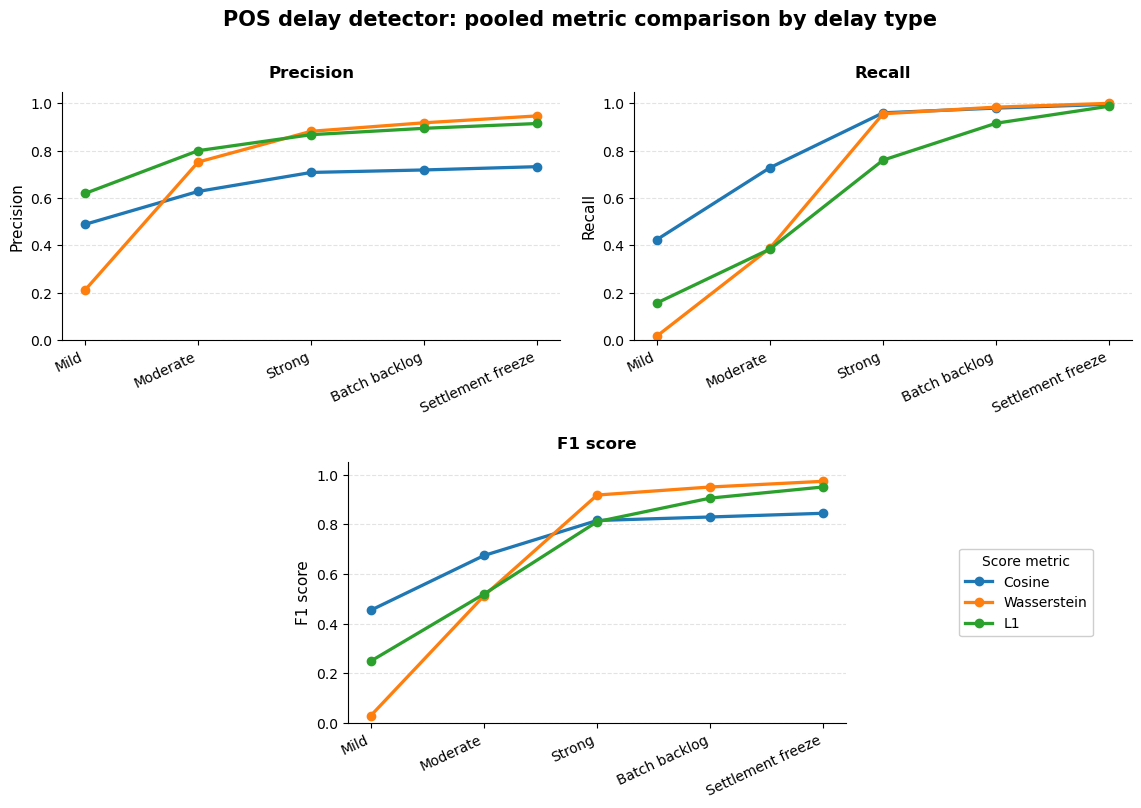

,score_col,delay_type_dataset,n_runs,n_gt_events,n_detected_events,tp,fp,fn,mean_iou_weighted_num,precision_pooled,recall_pooled,f1_pooled,mean_iou_pooled
0,pos_cos,mild_delay,5,250,217,106,111,144,56.576,0.488,0.424,0.454,0.534
1,pos_cos,moderate_delay,5,250,290,182,108,68,92.624,0.628,0.728,0.674,0.509
2,pos_cos,strong_delay,5,250,339,240,99,10,114.600,0.708,0.960,0.815,0.478
3,pos_cos,batch_backlog,5,250,341,245,96,5,110.202,0.718,0.980,0.829,0.450
4,pos_cos,settlement_freeze,5,250,340,249,91,1,100.418,0.732,0.996,0.844,0.403
5,pos_wasserstein,mild_delay,5,250,19,4,15,246,2.088,0.211,0.016,0.030,0.522
6,pos_wasserstein,moderate_delay,5,250,129,97,32,153,56.211,0.752,0.388,0.512,0.579
7,pos_wasserstein,strong_delay,5,250,271,239,32,11,121.447,0.882,0.956,0.917,0.508
8,pos_wasserstein,batch_backlog,5,250,268,246,22,4,108.313,0.918,0.984,0.950,0.440
9,pos_wasserstein,settlement_freeze,5,250,264,250,14,0,98.278,0.947,1.000,0.973,0.393


In [18]:
def plot_metric_dashboard_by_delay_type_score_metric(
    raw_results,
    save=True,
):
    """
    Cruscotto con:
    - in alto: Precision e Recall;
    - in basso centrato: F1.

    Asse x: tipo di POS delay.
    Linee: score metric usata dal detector.

    Le metriche sono pooled:
    - somma TP, FP, FN su tutti i dataset/seed;
    - calcola precision, recall e F1 dai conteggi aggregati.
    """

    plot_df = raw_results[
        raw_results["variation_group"] == "score_col"
    ].copy()

    if plot_df.empty:
        print("Nessun risultato disponibile per variation_group == 'score_col'.")
        return

    # -----------------------------
    # Ordine e label
    # -----------------------------
    delay_order = [
        "mild_delay",
        "moderate_delay",
        "strong_delay",
        "batch_backlog",
        "settlement_freeze",
    ]

    delay_labels = [
        "Mild",
        "Moderate",
        "Strong",
        "Batch backlog",
        "Settlement freeze",
    ]

    metric_order = [
        "pos_cos",
        "pos_wasserstein",
        "pos_l1",
    ]

    metric_labels = {
        "pos_cos": "Cosine",
        "pos_wasserstein": "Wasserstein",
        "pos_l1": "L1",
    }

    # -----------------------------
    # Aggregazione pooled
    # -----------------------------
    plot_df["mean_iou_weighted_num"] = (
        plot_df["mean_iou"].fillna(0) * plot_df["tp"].fillna(0)
    )

    summary = (
        plot_df
        .groupby(["score_col", "delay_type_dataset"], as_index=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            mean_iou_weighted_num=("mean_iou_weighted_num", "sum"),
        )
    )

    summary["precision_pooled"] = [
        pooled_precision(tp, fp)
        for tp, fp in zip(summary["tp"], summary["fp"])
    ]

    summary["recall_pooled"] = [
        pooled_recall(tp, fn)
        for tp, fn in zip(summary["tp"], summary["fn"])
    ]

    summary["f1_pooled"] = [
        pooled_f1(p, r)
        for p, r in zip(
            summary["precision_pooled"],
            summary["recall_pooled"],
        )
    ]

    summary["mean_iou_pooled"] = np.where(
        summary["tp"] > 0,
        summary["mean_iou_weighted_num"] / summary["tp"],
        np.nan,
    )

    summary["delay_type_dataset"] = pd.Categorical(
        summary["delay_type_dataset"],
        categories=delay_order,
        ordered=True,
    )

    summary["score_col"] = pd.Categorical(
        summary["score_col"],
        categories=metric_order,
        ordered=True,
    )

    summary = (
        summary
        .sort_values(["score_col", "delay_type_dataset"])
        .reset_index(drop=True)
    )

    x = np.arange(len(delay_order))

    # -----------------------------
    # Stile locale del grafico
    # -----------------------------
    with plt.rc_context({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
    }):

        fig = plt.figure(figsize=(13.8, 8.2))

        gs = fig.add_gridspec(
            nrows=2,
            ncols=4,
            height_ratios=[1.0, 1.05],
            hspace=0.48,
            wspace=0.35,
        )

        ax_precision = fig.add_subplot(gs[0, 0:2])
        ax_recall = fig.add_subplot(gs[0, 2:4])
        ax_f1 = fig.add_subplot(gs[1, 1:3])

        # Spazio vuoto in basso a destra usato per la legenda
        ax_legend = fig.add_subplot(gs[1, 3])
        ax_legend.axis("off")

        axes_info = [
            {
                "ax": ax_precision,
                "metric_col": "precision_pooled",
                "title": "Precision",
                "ylabel": "Precision",
            },
            {
                "ax": ax_recall,
                "metric_col": "recall_pooled",
                "title": "Recall",
                "ylabel": "Recall",
            },
            {
                "ax": ax_f1,
                "metric_col": "f1_pooled",
                "title": "F1 score",
                "ylabel": "F1 score",
            },
        ]

        # -----------------------------
        # Plot dei tre pannelli
        # -----------------------------
        for info in axes_info:
            ax = info["ax"]
            metric_col = info["metric_col"]

            for score_col, g in summary.groupby("score_col", observed=True):
                g = (
                    g
                    .set_index("delay_type_dataset")
                    .reindex(delay_order)
                    .reset_index()
                )

                y = g[metric_col].astype(float).to_numpy()

                ax.plot(
                    x,
                    y,
                    marker="o",
                    markersize=6,
                    linewidth=2.35,
                    label=metric_labels.get(str(score_col), str(score_col)),
                )

            ax.set_title(info["title"], pad=10)
            ax.set_ylabel(info["ylabel"])

            ax.set_xticks(x)
            ax.set_xticklabels(
                delay_labels,
                rotation=25,
                ha="right",
            )

            ax.set_ylim(0, 1.05)
            ax.grid(True, axis="y", linestyle="--", alpha=0.35)
            ax.grid(False, axis="x")

            # Niente xlabel: il tipo di delay è già leggibile dai tick.
            ax.set_xlabel("")

        # -----------------------------
        # Legenda nel riquadro vuoto
        # -----------------------------
        handles, labels = ax_precision.get_legend_handles_labels()

        ax_legend.legend(
            handles,
            labels,
            title="Score metric",
            loc="center",
            frameon=True,
            framealpha=0.95,
        )

        fig.suptitle(
            "POS delay detector: pooled metric comparison by delay type",
            fontsize=15,
            fontweight="bold",
            y=0.98,
        )

        fig.tight_layout(rect=[0, 0, 1, 0.95])

        if save:
            fig_path = (
                FIGURES_DIR
                / "dashboard_precision_recall_f1_by_delay_type_score_metric_pooled.png"
            )

            plt.savefig(
                fig_path,
                dpi=300,
                bbox_inches="tight",
            )

            print("Figura salvata:", fig_path)

        plt.show()

    return summary


metric_dashboard_by_delay_type_score_metric_pooled = (
    plot_metric_dashboard_by_delay_type_score_metric(
        raw_results,
        save=True,
    )
)

display(round_metric_cols(metric_dashboard_by_delay_type_score_metric_pooled))

Figura salvata: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\detector_sensitivity_one_at_a_time\figures\dashboard_parameter_sensitivity_2x2.png


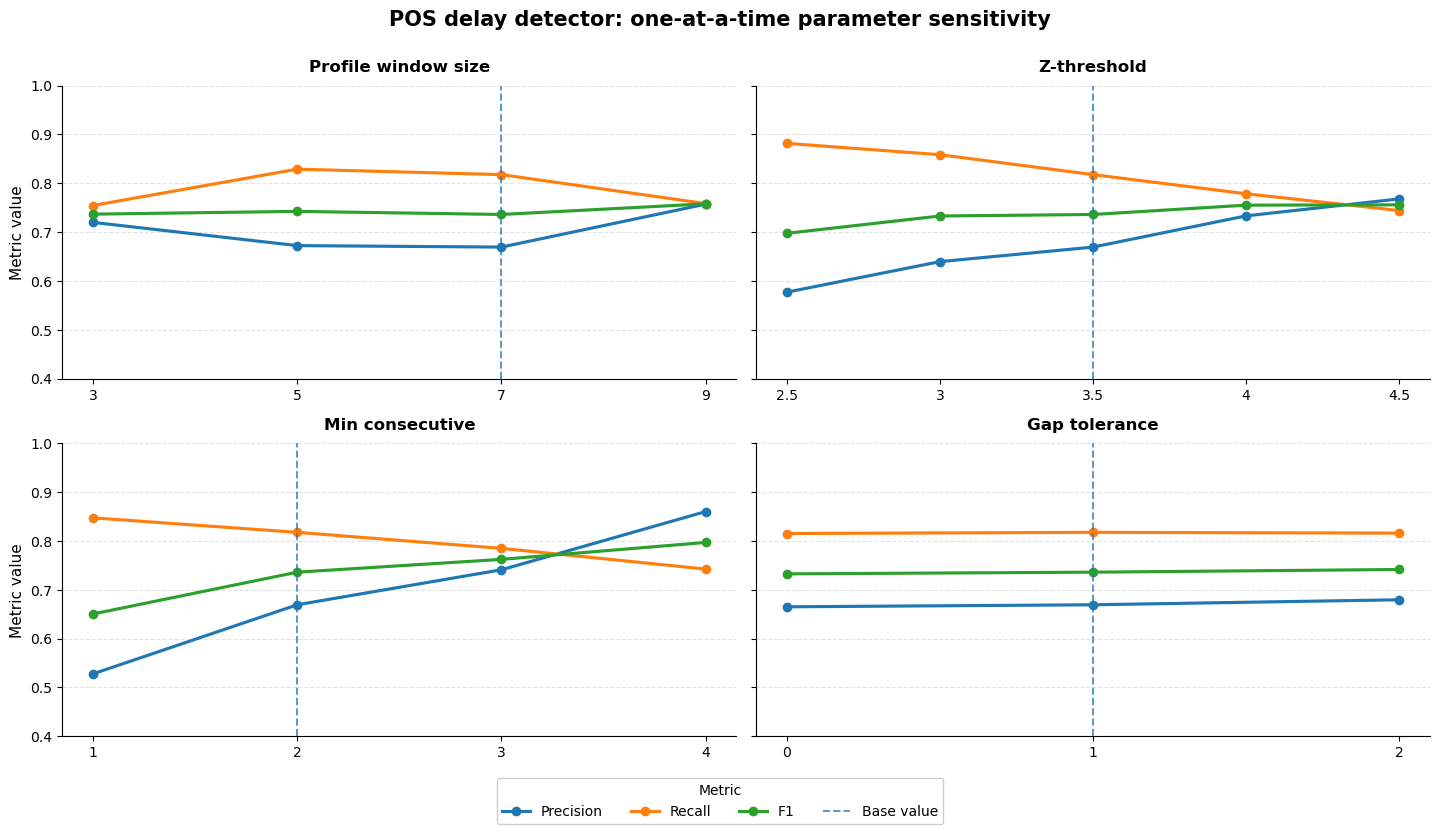

,varied_parameter,varied_value,varied_value_num,n_runs,n_gt_events,n_detected_events,tp,fp,fn,mean_iou_weighted_num,precision_pooled,recall_pooled,f1_pooled,mean_iou_pooled
0,gap_tolerance,0,0.0,25,1250,1532,1019,513,231,485.081,0.665,0.815,0.733,0.476
1,gap_tolerance,1,1.0,25,1250,1527,1022,505,228,474.420,0.669,0.818,0.736,0.464
2,gap_tolerance,2,2.0,25,1250,1501,1020,481,230,465.026,0.680,0.816,0.742,0.456
3,min_consecutive,1,1.0,25,1250,2006,1059,947,191,496.117,0.528,0.847,0.650,0.468
4,min_consecutive,2,2.0,25,1250,1527,1022,505,228,474.420,0.669,0.818,0.736,0.464
5,min_consecutive,3,3.0,25,1250,1324,981,343,269,448.925,0.741,0.785,0.762,0.458
6,min_consecutive,4,4.0,25,1250,1079,928,151,322,416.199,0.860,0.742,0.797,0.448
7,profile_window_size,3,3.0,25,1250,1310,943,367,307,487.436,0.720,0.754,0.737,0.517
8,profile_window_size,5,5.0,25,1250,1541,1036,505,214,532.186,0.672,0.829,0.742,0.514
9,profile_window_size,7,7.0,25,1250,1527,1022,505,228,474.420,0.669,0.818,0.736,0.464


In [19]:
def build_parameter_sensitivity_table(raw_results):
    """
    Aggrega i risultati one-at-a-time per parametro e valore.

    Le metriche sono pooled:
    - prima somma TP, FP, FN su tutti i dataset/seed;
    - poi calcola precision, recall e F1 dai conteggi aggregati.
    """

    parameter_list = [
        "profile_window_size",
        "z_threshold",
        "min_consecutive",
        "gap_tolerance",
    ]

    df = raw_results[
        raw_results["variation_group"].isin(parameter_list)
    ].copy()

    df["varied_value_num"] = pd.to_numeric(
        df["varied_value"],
        errors="coerce",
    )

    df["mean_iou_weighted_num"] = (
        df["mean_iou"].fillna(0) * df["tp"].fillna(0)
    )

    agg = (
        df
        .groupby(
            ["varied_parameter", "varied_value", "varied_value_num"],
            as_index=False,
        )
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            mean_iou_weighted_num=("mean_iou_weighted_num", "sum"),
        )
    )

    agg["precision_pooled"] = [
        pooled_precision(tp, fp)
        for tp, fp in zip(agg["tp"], agg["fp"])
    ]

    agg["recall_pooled"] = [
        pooled_recall(tp, fn)
        for tp, fn in zip(agg["tp"], agg["fn"])
    ]

    agg["f1_pooled"] = [
        pooled_f1(p, r)
        for p, r in zip(agg["precision_pooled"], agg["recall_pooled"])
    ]

    agg["mean_iou_pooled"] = np.where(
        agg["tp"] > 0,
        agg["mean_iou_weighted_num"] / agg["tp"],
        np.nan,
    )

    return agg


def get_parameter_curve(agg_df, parameter):
    """
    Estrae la curva pooled relativa a un singolo parametro.
    """

    g = agg_df[
        agg_df["varied_parameter"] == parameter
    ].copy()

    g = (
        g
        .dropna(subset=["varied_value_num"])
        .sort_values("varied_value_num")
        .reset_index(drop=True)
    )

    return g


def plot_parameter_sensitivity_dashboard(
    raw_results,
    parameters=None,
    save=True,
):
    """
    Cruscotto 2x2 della sensitivity one-at-a-time.

    Ogni subplot mostra precision, recall e F1 pooled
    al variare di un singolo parametro del detector.
    """

    if parameters is None:
        parameters = [
            "profile_window_size",
            "z_threshold",
            "min_consecutive",
            "gap_tolerance",
        ]

    if len(parameters) != 4:
        raise ValueError("Per il cruscotto 2x2 servono esattamente 4 parametri.")

    parameter_labels = {
        "profile_window_size": "Profile window size",
        "z_threshold": "Z-threshold",
        "min_consecutive": "Min consecutive",
        "gap_tolerance": "Gap tolerance",
    }

    metric_specs = [
        ("precision_pooled", "Precision"),
        ("recall_pooled", "Recall"),
        ("f1_pooled", "F1"),
    ]

    agg_df = build_parameter_sensitivity_table(raw_results)

    with plt.rc_context({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
    }):

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(14.5, 8.6),
            sharex=False,
            sharey=True,
        )

        axes = axes.flatten()

        for i, (ax, parameter) in enumerate(zip(axes, parameters)):

            g = get_parameter_curve(agg_df, parameter)

            if g.empty:
                ax.set_title(parameter_labels.get(parameter, parameter))
                ax.text(
                    0.5,
                    0.5,
                    "Nessun dato",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_ylim(0.4, 1.0)
                ax.set_yticks(np.arange(0.4, 1.01, 0.1))
                continue

            x = g["varied_value_num"].astype(float).to_numpy()

            for metric_col, metric_label in metric_specs:
                ax.plot(
                    x,
                    g[metric_col],
                    marker="o",
                    markersize=6,
                    linewidth=2.25,
                    label=metric_label,
                )

            if parameter in BASE_CONFIG:
                ax.axvline(
                    BASE_CONFIG[parameter],
                    linestyle="--",
                    linewidth=1.4,
                    alpha=0.75,
                    label="Base value" if i == 0 else None,
                )

            ax.set_title(
                parameter_labels.get(parameter, parameter),
                pad=10,
            )

            ax.set_ylim(0.4, 1.0)
            ax.set_yticks(np.arange(0.4, 1.01, 0.1))

            ax.grid(
                True,
                axis="y",
                linestyle="--",
                alpha=0.35,
            )
            ax.grid(False, axis="x")

            x_ticks = sorted(g["varied_value_num"].dropna().unique())
            ax.set_xticks(x_ticks)
            ax.xaxis.set_major_formatter(FormatStrFormatter("%.3g"))

            # Niente xlabel: il nome del parametro è già nel titolo.
            ax.set_xlabel("")

            if i % 2 == 0:
                ax.set_ylabel("Metric value")
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)

        handles, labels = axes[0].get_legend_handles_labels()

        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=4,
            bbox_to_anchor=(0.5, -0.015),
            title="Metric",
        )

        fig.suptitle(
            "POS delay detector: one-at-a-time parameter sensitivity",
            fontsize=15,
            fontweight="bold",
            y=0.94,
        )

        fig.tight_layout(rect=[0, 0.05, 1, 0.94])

        if save:
            fig_path = FIGURES_DIR / "dashboard_parameter_sensitivity_2x2.png"
            fig.savefig(
                fig_path,
                dpi=300,
                bbox_inches="tight",
            )
            print("Figura salvata:", fig_path)

        plt.show()
        plt.close(fig)

    return agg_df


parameter_sensitivity_dashboard_table = plot_parameter_sensitivity_dashboard(
    raw_results,
    save=True,
)

display(round_metric_cols(parameter_sensitivity_dashboard_table))

Figura salvata: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\detector_sensitivity_one_at_a_time\figures\dashboard_f1_by_delay_type_parameter_values.png


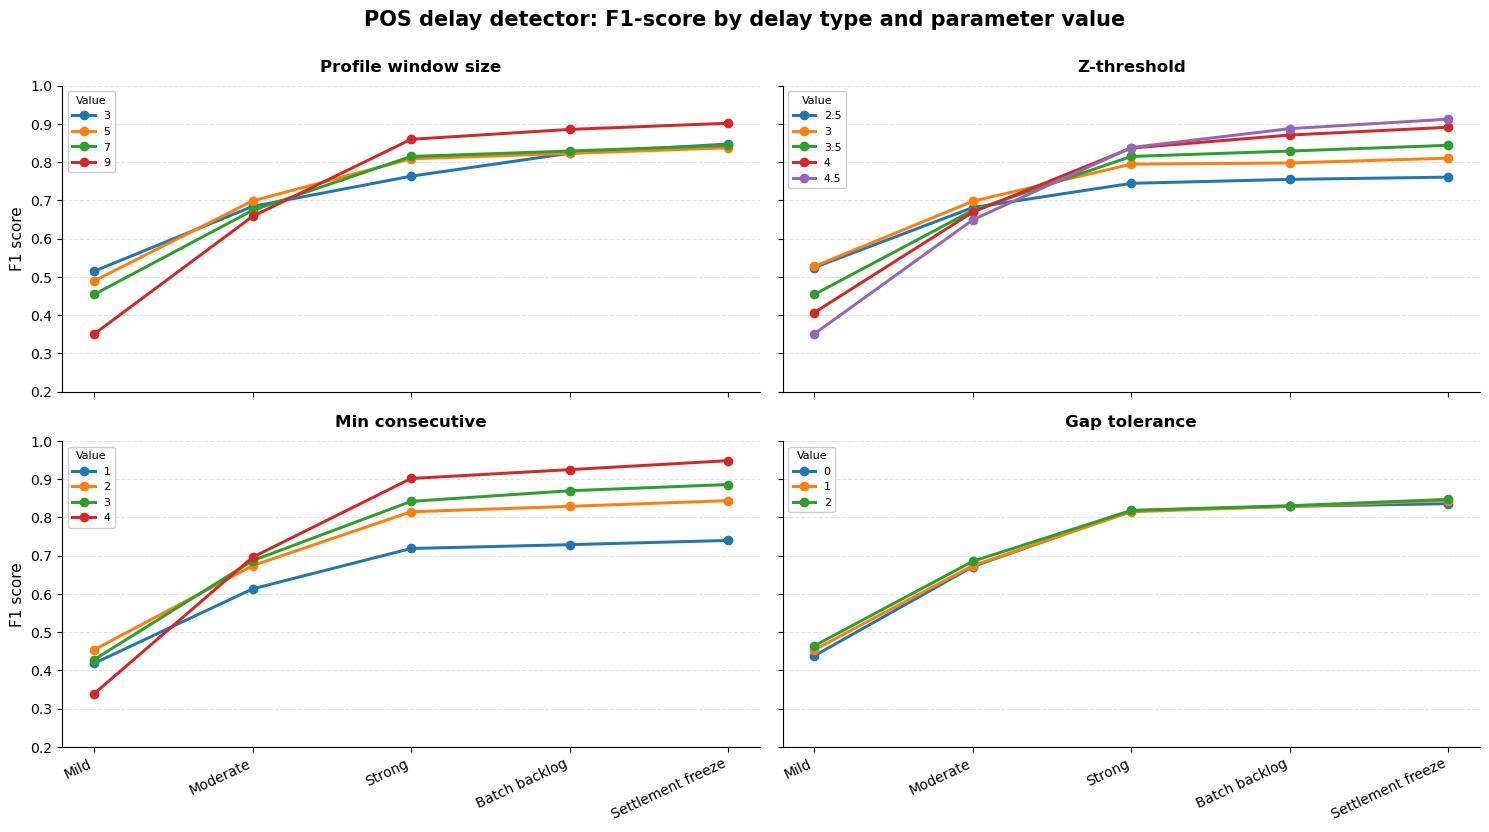

,varied_parameter,varied_value,varied_value_num,delay_type_dataset,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled
0,gap_tolerance,0,0.0,mild_delay,5,250,211,101,110,149,0.479,0.404,0.438
1,gap_tolerance,0,0.0,moderate_delay,5,250,295,183,112,67,0.620,0.732,0.672
2,gap_tolerance,0,0.0,strong_delay,5,250,337,240,97,10,0.712,0.960,0.818
3,gap_tolerance,0,0.0,batch_backlog,5,250,341,245,96,5,0.718,0.980,0.829
4,gap_tolerance,0,0.0,settlement_freeze,5,250,348,250,98,0,0.718,1.000,0.836
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,z_threshold,4.5,4.5,mild_delay,5,250,126,66,60,184,0.524,0.264,0.351
76,z_threshold,4.5,4.5,moderate_delay,5,250,212,150,62,100,0.708,0.600,0.649
77,z_threshold,4.5,4.5,strong_delay,5,250,282,223,59,27,0.791,0.892,0.838
78,z_threshold,4.5,4.5,batch_backlog,5,250,293,241,52,9,0.823,0.964,0.888


In [20]:
def build_f1_by_delay_type_param_value(raw_results, parameters=None):
    """
    Costruisce una tabella pooled per:
    - parametro variato;
    - valore del parametro;
    - tipo di POS delay.

    Le metriche sono pooled:
    somma TP, FP, FN e poi calcolo di precision, recall e F1.
    """

    if parameters is None:
        parameters = [
            "profile_window_size",
            "z_threshold",
            "min_consecutive",
            "gap_tolerance",
        ]

    df = raw_results[
        raw_results["variation_group"].isin(parameters)
    ].copy()

    df["varied_value_num"] = pd.to_numeric(
        df["varied_value"],
        errors="coerce",
    )

    agg = (
        df
        .groupby(
            [
                "varied_parameter",
                "varied_value",
                "varied_value_num",
                "delay_type_dataset",
            ],
            as_index=False,
        )
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
        )
    )

    agg["precision_pooled"] = [
        pooled_precision(tp, fp)
        for tp, fp in zip(agg["tp"], agg["fp"])
    ]

    agg["recall_pooled"] = [
        pooled_recall(tp, fn)
        for tp, fn in zip(agg["tp"], agg["fn"])
    ]

    agg["f1_pooled"] = [
        pooled_f1(p, r)
        for p, r in zip(
            agg["precision_pooled"],
            agg["recall_pooled"],
        )
    ]

    return agg


def plot_f1_by_delay_type_parameter_dashboard(
    raw_results,
    parameters=None,
    save=True,
):
    """
    Dashboard 2x2 della F1 pooled per tipo di POS delay.

    Ogni pannello corrisponde a un parametro del detector.
    In ciascun pannello:
    - asse x: tipo di POS delay;
    - asse y: F1 pooled;
    - linee: valori diversi del parametro considerato.
    """

    if parameters is None:
        parameters = [
            "profile_window_size",
            "z_threshold",
            "min_consecutive",
            "gap_tolerance",
        ]

    if len(parameters) != 4:
        raise ValueError("Per il cruscotto 2x2 servono esattamente 4 parametri.")

    delay_order = [
        "mild_delay",
        "moderate_delay",
        "strong_delay",
        "batch_backlog",
        "settlement_freeze",
    ]

    delay_labels = [
        "Mild",
        "Moderate",
        "Strong",
        "Batch backlog",
        "Settlement freeze",
    ]

    parameter_labels = {
        "profile_window_size": "Profile window size",
        "z_threshold": "Z-threshold",
        "min_consecutive": "Min consecutive",
        "gap_tolerance": "Gap tolerance",
    }

    agg_df = build_f1_by_delay_type_param_value(
        raw_results,
        parameters=parameters,
    )

    agg_df["delay_type_dataset"] = pd.Categorical(
        agg_df["delay_type_dataset"],
        categories=delay_order,
        ordered=True,
    )

    agg_df = (
        agg_df
        .sort_values(
            [
                "varied_parameter",
                "varied_value_num",
                "delay_type_dataset",
            ]
        )
        .reset_index(drop=True)
    )

    x = np.arange(len(delay_order))

    with plt.rc_context({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
    }):

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(15.0, 8.8),
            sharex=True,
            sharey=True,
        )

        axes = axes.flatten()

        for i, (ax, parameter) in enumerate(zip(axes, parameters)):

            row_idx = i // 2
            col_idx = i % 2

            g = agg_df[
                agg_df["varied_parameter"] == parameter
            ].copy()

            if g.empty:
                ax.set_title(parameter_labels.get(parameter, parameter))
                ax.text(
                    0.5,
                    0.5,
                    "Nessun dato",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_ylim(0.2, 1.0)
                ax.set_yticks(np.arange(0.2, 1.01, 0.1))
                continue

            for value, gv in g.groupby("varied_value_num", sort=True):
                gv = (
                    gv
                    .set_index("delay_type_dataset")
                    .reindex(delay_order)
                    .reset_index()
                )

                ax.plot(
                    x,
                    gv["f1_pooled"],
                    marker="o",
                    markersize=6,
                    linewidth=2.15,
                    label=f"{value:g}",
                )

            ax.set_title(
                parameter_labels.get(parameter, parameter),
                pad=10,
            )

            ax.set_ylim(0.2, 1.0)
            ax.set_yticks(np.arange(0.2, 1.01, 0.1))

            ax.set_xticks(x)
            ax.set_xticklabels(
                delay_labels,
                rotation=25,
                ha="right",
            )

            ax.grid(
                True,
                axis="y",
                linestyle="--",
                alpha=0.35,
            )
            ax.grid(False, axis="x")

            if row_idx == 1:
                ax.tick_params(labelbottom=True)
            else:
                ax.tick_params(labelbottom=False)

            if col_idx == 0:
                ax.set_ylabel("F1 score")
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)

            ax.legend(
                title="Value",
                fontsize=8,
                title_fontsize=8,
                loc="best",
            )

        fig.suptitle(
            "POS delay detector: F1-score by delay type and parameter value",
            fontsize=15,
            fontweight="bold",
            y=0.94,
        )

        fig.tight_layout(rect=[0, 0, 1, 0.94])

        if save:
            fig_path = FIGURES_DIR / "dashboard_f1_by_delay_type_parameter_values.png"

            fig.savefig(
                fig_path,
                dpi=300,
                bbox_inches="tight",
            )

            print("Figura salvata:", fig_path)

        plt.show()
        plt.close(fig)

    return agg_df


f1_by_delay_type_parameter_dashboard_table = (
    plot_f1_by_delay_type_parameter_dashboard(
        raw_results,
        save=True,
    )
)

display(round_metric_cols(f1_by_delay_type_parameter_dashboard_table))

## Salvataggio delle tabelle

Le aggregazioni e i punti utilizzati nei grafici vengono salvati nella sottocartella `tables`. I risultati raw sono già salvati immediatamente dopo l'esecuzione della griglia.

In [21]:
# =========================================================
# SAVE TABLES
# =========================================================

# Risultati grezzi e aggregazioni principali.
raw_results.to_csv(RAW_RESULTS_PATH, index=False)
by_type_results.to_csv(BY_TYPE_RESULTS_PATH, index=False)

base_summary.to_csv(
    TABLES_DIR / "base_config_summary.csv",
    index=False,
)

base_by_type_summary.to_csv(
    TABLES_DIR / "base_config_summary_by_type.csv",
    index=False,
)

parameter_summary.to_csv(
    TABLES_DIR / "parameter_sensitivity_summary.csv",
    index=False,
)

parameter_by_type_summary.to_csv(
    TABLES_DIR / "parameter_sensitivity_summary_by_type.csv",
    index=False,
)

# Punti utilizzati nei grafici.
parameter_sensitivity_dashboard_table.to_csv(
    TABLES_DIR / "parameter_sensitivity_dashboard_points.csv",
    index=False,
)

f1_by_delay_type_parameter_dashboard_table.to_csv(
    TABLES_DIR / "f1_by_delay_type_parameter_dashboard_points.csv",
    index=False,
)

print("Risultati salvati in:", OUTPUT_DIR)
OUTPUT_DIR

Risultati salvati in: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\detector_sensitivity_one_at_a_time


WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/detector_sensitivity_one_at_a_time')